In [1]:
import rds2py
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pds


In [2]:
r_obj = rds2py.read_rds("data/HT224P1-S1.rds")

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/rds2py/PyRdsReader.py:105: RuntimeWarning: Unsupported R object type: other
  warn(f"Unsupported R object type: {rtype}", RuntimeWarning)
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/rds2py/generics.py:145: RuntimeWarning: RDS file contains an unknown class: 'Seurat', returning the dictionary
  warn(


In [10]:
import scanpy as sc
import anndata
file_dir = "data/data_h5ad/HT224P1-S1.h5ad"
data = sc.read(file_dir)

In [11]:
data

AnnData object with n_obs × n_vars = 2798 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Piece_ID', 'cell_type', 'Original_barcode'
    var: 'features'

In [25]:
#import libraries
import scanpy as sc
import cell2location as c2l
import squidpy as sq

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

#lire les données 
adata_sc = sc.read("data/data_h5ad/HT224P1-S1.h5ad") # mettre le nom du fichier scRNAseq


adata_st = sc.read("data/data_h5ad/HT224P1-S1Fc2U1Z1Bs1-SeuratObj.h5ad") # mettre le nom du fichier spatial

print(adata_sc)
print(adata_st)

AnnData object with n_obs × n_vars = 2798 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Piece_ID', 'cell_type', 'Original_barcode'
    var: 'features'
AnnData object with n_obs × n_vars = 2295 × 3000
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent_mt', 'percent_rb', 'percent_hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'Tumor_purity_estimate'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'


/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [36]:
adata_sc.obs

,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,seurat_clusters,Piece_ID,cell_type,Original_barcode
PDAC_HT224P1-S1_AAACAGCCAGTAATAG-1,1243.0,867,0.804505,2424.0,872,1,HT224P1-S1,T-cells,AAACAGCCAGTAATAG-1
PDAC_HT224P1-S1_AAACAGCCATAGACCC-1,5657.0,2723,0.088386,3843.0,2573,24,HT224P1-S1,Macrophages,AAACAGCCATAGACCC-1
PDAC_HT224P1-S1_AAACAGCCATCAATCG-1,3964.0,2036,0.151362,3547.0,2036,24,HT224P1-S1,Macrophages,AAACAGCCATCAATCG-1
PDAC_HT224P1-S1_AAACATGCAATAATGG-1,1377.0,920,0.217865,2544.0,922,1,HT224P1-S1,T-cells,AAACATGCAATAATGG-1
PDAC_HT224P1-S1_AAACCAACACCTCAGG-1,7416.0,3568,0.134844,3620.0,2519,25,HT224P1-S1,Tumor,AAACCAACACCTCAGG-1
...,...,...,...,...,...,...,...,...,...
PDAC_HT224P1-S1_TTTGTGTTCCTAAATG-1,2338.0,1360,1.411463,2596.0,1360,1,HT224P1-S1,T-cells,TTTGTGTTCCTAAATG-1
PDAC_HT224P1-S1_TTTGTGTTCCTAATTC-1,2643.0,1496,0.075672,2733.0,1496,13,HT224P1-S1,Plasma,TTTGTGTTCCTAATTC-1
PDAC_HT224P1-S1_TTTGTGTTCGTGCCTT-1,3256.0,2236,0.122850,3246.0,2236,25,HT224P1-S1,Tumor,TTTGTGTTCGTGCCTT-1
PDAC_HT224P1-S1_TTTGTTGGTAACAGGG-1,7475.0,3468,0.107023,3572.0,2440,25,HT224P1-S1,Tumor,TTTGTTGGTAACAGGG-1


In [34]:
adata_st.var

,features
LINC02593,LINC02593
SAMD11,SAMD11
HES4,HES4
ISG15,ISG15
AGRN,AGRN
...,...
MT-ND4L,MT-ND4L
MT-ND4,MT-ND4
MT-ND5,MT-ND5
MT-CYB,MT-CYB


In [23]:
sq.pl.spatial_scatter(adata_st, library_key="X_pca")

KeyError: 'Spatial basis `spatial` not found in `adata.obsm`.'

In [24]:
sc.pl.umap(adata_sc, color="cell_type_original")

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

In [ ]:
adata_st.var.head()

In [ ]:
adata_st.var["feature_name"] = adata_st.var_names
adata_st.var.set_index("gene_ids", drop=True, inplace=True)

adata_st.var.head()

In [ ]:
#gènes mitochondriaux

# find mitochondrial (MT) genes
adata_st.var["MT_gene"] = [
    gene.startswith("MT-") for gene in adata_st.var["feature_name"]
]

# remove MT genes for spatial mapping (keeping their counts in the object)
adata_st.obsm["MT"] = adata_st[:, adata_st.var["MT_gene"].values].X.toarray()
adata_st = adata_st[:, ~adata_st.var["MT_gene"].values]

In [ ]:
shared_features = [
    feature for feature in adata_st.var_names if feature in adata_sc.var_names
]
adata_sc = adata_sc[:, shared_features].copy()
adata_st = adata_st[:, shared_features].copy()

In [42]:
#configurer et entrainer sur scRNAseq
adata_sc_filtered = adata_sc[adata_sc.obs['cell_type'] != 'low quality', :].copy()
c2l.models.RegressionModel.setup_anndata(
    adata=adata_sc_filtered,
    labels_key="cell_type"
)

model = c2l.models.RegressionModel(adata_sc_filtered)

model.train(max_epochs=250, batch_size=2500, train_size=1, lr=0.002)




/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 0 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.p

Training:   0%|          | 0/250 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=250` reached.


In [44]:
model.save("models/sc_regression", overwrite=True)

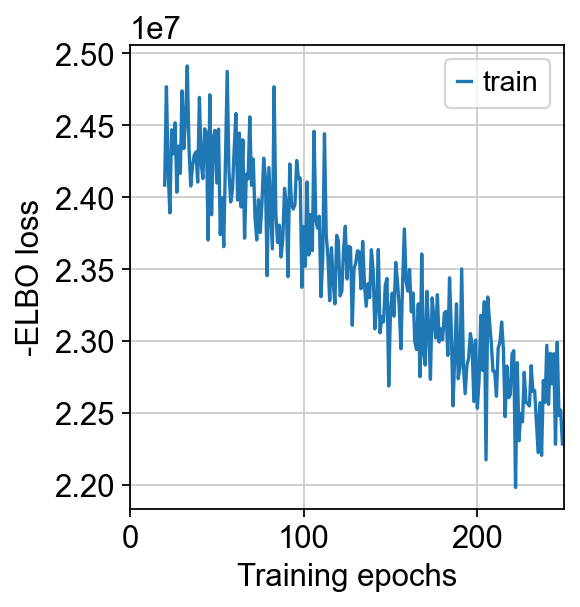

In [43]:
model.plot_history(20)


In [ ]:
# Exporter signatures

model.export_posterior(
    adata_sc,
    sample_kwargs={"num_samples": 1000, "batch_size": 2500, "use_gpu": use_gpu},
)

inf_aver = adata_sc.varm['means_per_cluster_mu_fg']  # genes x cell_types
inf_aver.to_csv('signatures.csv')  # réutilisable

In [ ]:
mod_ref.plot_QC()  # diagonal reconstruction

In [ ]:
#modele spatial (deconvolution)

c2l.models.Cell2location.setup_anndata(adata_st, batch_key='features')
mod_sp = c2l.models.Cell2location(adata_st, cell_state_df=inf_aver,
                                  N_cells_per_location=8)  # ~8 cellules/spot

mod_sp.train(max_epochs=30000)  # plus long, GPU recommandé
mod_sp.plot_history()  # convergence
mod_sp.plot_QC()  # diagonal

# Exporter abondances (q05 = confiance haute)
adata_st = mod_sp.export_posterior(adata_st, 
                                   sample_kwargs={'num_samples':1000})
adata_st.obs[mod_sp.factor_names_] = adata_st.obsm['q05_cell_abundance_w_sf']


In [ ]:
#visualization et validation

sc.pl.spatial(adata_st, color=['T-cells', 'Tumor'], 
              img_key='hires', vmin=0, vmax='p99')
sq.pl.spatial_scatter(adata_st, color='region_cluster')  # après clustering

# Clustering régions tissulaires
sc.pp.neighbors(adata_st, use_rep='q05_cell_abundance_w_sf')
sc.tl.leiden(adata_st)
sc.tl.umap(adata_st)

